# Notebook 00C_C — Análise Comparativa: NIH × CheXpert

**Carrega apenas CSVs — zero I/O de imagem — rápido**

Rodar após 00C_A e 00C_B para consolidar análise comparativa (Seções 5 e 15).

## Célula 1 — Dependências

In [ ]:
!pip install -q pandas numpy matplotlib seaborn Pillow tqdm
print('Dependências instaladas.')

Dependências instaladas.


## Célula 2 — Drive, caminhos e pasta de saída

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

BASE_DRIVE  = '/content/drive/MyDrive'
DATASET_DIR = f'{BASE_DRIVE}/datasets_pi_2026'

NIH_SSD_DIR = '/content/NIH_CHEST_XRAYS'
NIH_DIR     = f'{DATASET_DIR}/NIH_CHEST_XRAYS'
NIH_ACTIVE  = NIH_SSD_DIR if os.path.exists(NIH_SSD_DIR) else NIH_DIR

CHEX_DIR     = f'{DATASET_DIR}/CheXpert_extracted'
CHEX_CSV_DIR = f'{CHEX_DIR}/meta'

RESULTS_DIR  = f'{BASE_DRIVE}/Results'
ANALYSIS_DIR = f'{RESULTS_DIR}/analise_Comparativo'
PLOTS_DIR    = f'{ANALYSIS_DIR}/plots'
TABLES_DIR   = f'{ANALYSIS_DIR}/tabelas'
REPORT_PATH  = f'{ANALYSIS_DIR}/relatorio_comparativo.txt'

for d in [ANALYSIS_DIR, PLOTS_DIR, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

print('Caminhos configurados.')


Mounted at /content/drive
Caminhos configurados.


## Célula 3 — Imports, constantes e utilitários

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from itertools import combinations
import glob, warnings, time, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False
})

C_NIH  = '#185FA5'
C_CHEX = '#0F6E56'
C_WARN = '#D85A30'
C_AMB  = '#854F0B'
C_GRAY = '#888780'

NIH_LABELS = [
    'Atelectasis','Cardiomegaly','Effusion','Infiltration',
    'Mass','Nodule','Pneumonia','Pneumothorax',
    'Consolidation','Edema','Emphysema','Fibrosis',
    'Pleural_Thickening','Hernia'
]
CHEX_LABELS = [
    'Atelectasis','Cardiomegaly','Consolidation','Edema',
    'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
    'Lung Opacity','No Finding','Pleural Effusion',
    'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
]
CHEX_LABELS_NO_NF = [l for l in CHEX_LABELS if l != 'No Finding']

NIH_TO_CHEX = {
    'Atelectasis': 'Atelectasis', 'Cardiomegaly': 'Cardiomegaly',
    'Effusion': 'Pleural Effusion', 'Pneumonia': 'Pneumonia',
    'Pneumothorax': 'Pneumothorax', 'Consolidation': 'Consolidation',
    'Edema': 'Edema',
}

REPORT_LINES = []

def log(msg=''):
    print(msg)
    REPORT_LINES.append(msg)

def save_fig(fig, path, tight=True):
    if tight:
        plt.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Salvo: {path.replace(BASE_DRIVE, "MyDrive")}')

def section(title):
    log()
    log('=' * 65)
    log(title)
    log('=' * 65)

print('Imports e utilitários prontos.')


Imports e utilitários prontos.


## Célula 4 — Carregar datasets (CSV apenas, sem imagens)

In [ ]:
# Este notebook carrega APENAS CSVs — sem leitura de imagens
# Propositalmente leve: análise comparativa pura

df_nih = pd.read_csv(f'{NIH_ACTIVE}/Data_Entry_2017.csv')
for lbl in NIH_LABELS:
    df_nih[lbl] = df_nih['Finding Labels'].apply(
        lambda x: 1 if lbl in str(x).split('|') else 0)

df_chex_train = pd.read_csv(f'{CHEX_CSV_DIR}/train.csv')
df_chex_valid = pd.read_csv(f'{CHEX_CSV_DIR}/valid.csv')
df_chex_valid['split'] = 'valid'
df_chex_train['split'] = 'train'
df_chex = pd.concat([df_chex_train, df_chex_valid], ignore_index=True)

if 'Frontal/Lateral' in df_chex_train.columns:
    df_chex_train['view_type'] = df_chex_train['Frontal/Lateral']

print(f'NIH carregado   : {len(df_nih):,} imagens')
print(f'CheXpert carregado: {len(df_chex):,} imagens')
print('Sem leitura de imagem — apenas metadados CSV.')


NIH carregado   : 112,120 imagens
CheXpert carregado: 223,648 imagens
Sem leitura de imagem — apenas metadados CSV.


---
# SEÇÃO 5 — Prevalência Comparada NIH vs CheXpert


SEÇÃO 5 — Prevalência Comparada NIH vs CheXpert
Patologia                 NIH %   CheXpert %    Diferença
--------------------------------------------------------
Atelectasis               10.31%       14.94%       +4.63%
Cardiomegaly               2.48%       12.09%       +9.61%
Effusion                  11.88%       38.58%      +26.70%
Pneumonia                  1.28%        2.70%       +1.43%
Pneumothorax               4.73%        8.70%       +3.98%
Consolidation              4.16%        6.62%       +2.45%
Edema                      2.05%       23.39%      +21.33%


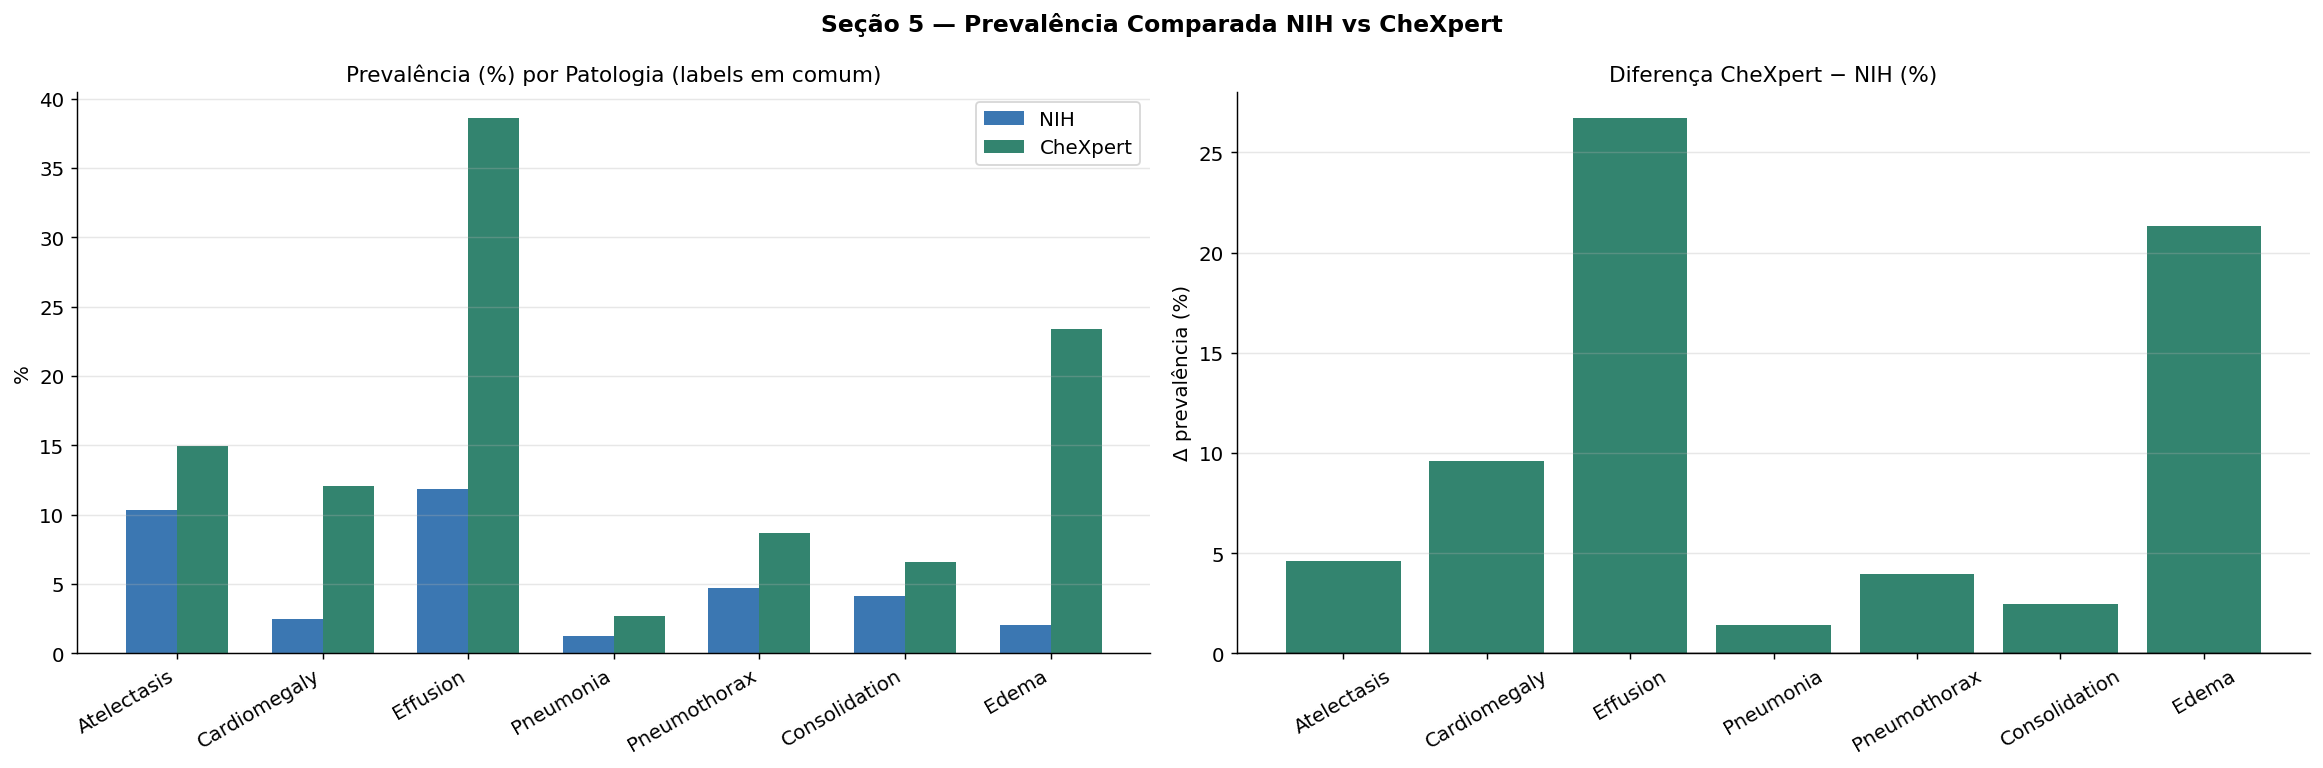

  Salvo: MyDrive/Results/analise_Comparativo/plots/05_prevalence_comparison.png


In [ ]:
section('SEÇÃO 5 — Prevalência Comparada NIH vs CheXpert')

compare_data = []
log(f'{"Patologia":<20} {"NIH %":>10} {"CheXpert %":>12} {"Diferença":>12}')
log('-' * 56)

for nih_lbl, chex_lbl in NIH_TO_CHEX.items():
    nih_p  = df_nih[nih_lbl].mean()*100 if nih_lbl in df_nih.columns else 0
    chex_p = (df_chex_train[chex_lbl]==1).mean()*100 if chex_lbl in df_chex_train.columns else 0
    diff   = chex_p - nih_p
    log(f'{nih_lbl:<20} {nih_p:>10.2f}% {chex_p:>11.2f}% {diff:>+11.2f}%')
    compare_data.append({'patologia': nih_lbl, 'nih_pct': nih_p, 'chex_pct': chex_p, 'diff': diff})

df_compare = pd.DataFrame(compare_data)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Seção 5 — Prevalência Comparada NIH vs CheXpert', fontsize=13, fontweight='bold')

x = np.arange(len(df_compare)); w = 0.35
axes[0].bar(x-w/2, df_compare['nih_pct'],  w, label='NIH',      color=C_NIH,  alpha=0.85)
axes[0].bar(x+w/2, df_compare['chex_pct'], w, label='CheXpert', color=C_CHEX, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_compare['patologia'], rotation=30, ha='right')
axes[0].set_title('Prevalência (%) por Patologia (labels em comum)')
axes[0].set_ylabel('%'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

colors_diff = [C_CHEX if v >= 0 else C_WARN for v in df_compare['diff']]
axes[1].bar(df_compare['patologia'], df_compare['diff'], color=colors_diff, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Diferença CheXpert − NIH (%)'); axes[1].set_ylabel('Δ prevalência (%)')
axes[1].tick_params(axis='x', rotation=30); axes[1].grid(axis='y', alpha=0.3)

save_fig(fig, f'{PLOTS_DIR}/05_prevalence_comparison.png')
df_compare.to_csv(f'{TABLES_DIR}/05_prevalence_comparison.csv', index=False)


---
# SEÇÃO 15 — Viés Demográfico: NIH vs CheXpert


SEÇÃO 15 — Viés Demográfico: NIH vs CheXpert
Distribuição de sexo:
  NIH      : {'M': np.float64(56.5), 'F': np.float64(43.5)}
  CheXpert : {'Male': np.float64(59.4), 'Female': np.float64(40.6), 'Unknown': np.float64(0.0)}

Distribuição de idade:
  NIH      : média=46.9 | std=16.8
  CheXpert : média=60.4 | std=17.8


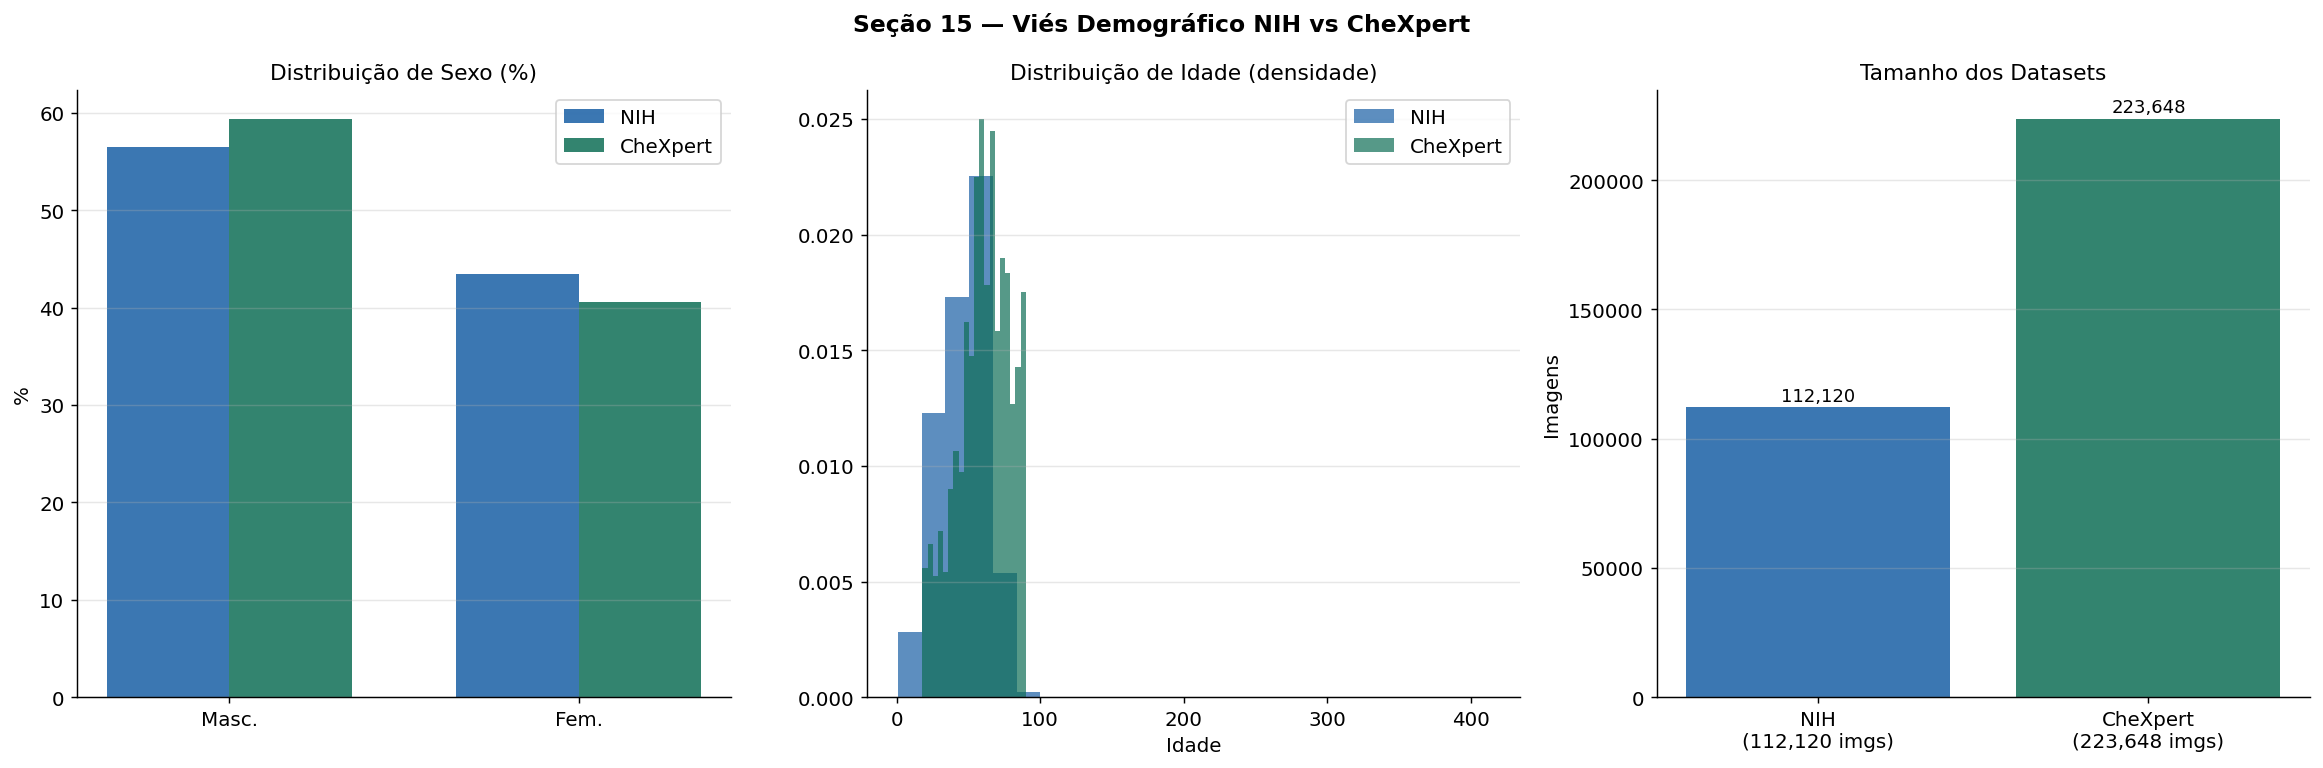

  Salvo: MyDrive/Results/analise_Comparativo/plots/15_demographic_bias.png


In [ ]:
section('SEÇÃO 15 — Viés Demográfico: NIH vs CheXpert')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Seção 15 — Viés Demográfico NIH vs CheXpert', fontsize=13, fontweight='bold')

# ── Sexo ─────────────────────────────────────────────────
age_col_nih  = 'Patient Age'  if 'Patient Age'  in df_nih.columns        else None
age_col_chex = 'Age'          if 'Age'          in df_chex_train.columns  else None

if 'Patient Gender' in df_nih.columns and 'Sex' in df_chex_train.columns:
    nih_gender  = df_nih['Patient Gender'].value_counts(normalize=True)*100
    chex_gender = df_chex_train['Sex'].value_counts(normalize=True)*100

    log('Distribuição de sexo:')
    log(f'  NIH      : {dict(nih_gender.round(1))}')
    log(f'  CheXpert : {dict(chex_gender.round(1))}')

    x = np.arange(2); w = 0.35
    nih_vals  = [nih_gender.get('M', 0), nih_gender.get('F', 0)]
    chex_vals = [chex_gender.get('Male', 0), chex_gender.get('Female', 0)]
    axes[0].bar(x-w/2, nih_vals,  w, label='NIH',      color=C_NIH,  alpha=0.85)
    axes[0].bar(x+w/2, chex_vals, w, label='CheXpert', color=C_CHEX, alpha=0.85)
    axes[0].set_xticks(x); axes[0].set_xticklabels(['Masc.','Fem.'])
    axes[0].set_title('Distribuição de Sexo (%)'); axes[0].set_ylabel('%'); axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

# ── Idade ────────────────────────────────────────────────
if age_col_nih and age_col_chex:
    nih_age_clean  = df_nih[age_col_nih].dropna()
    chex_age_clean = df_chex_train[age_col_chex].dropna()

    log('\nDistribuição de idade:')
    log(f'  NIH      : média={nih_age_clean.mean():.1f} | std={nih_age_clean.std():.1f}')
    log(f'  CheXpert : média={chex_age_clean.mean():.1f} | std={chex_age_clean.std():.1f}')

    axes[1].hist(nih_age_clean,  bins=25, alpha=0.7, label='NIH',      color=C_NIH,  density=True)
    axes[1].hist(chex_age_clean, bins=25, alpha=0.7, label='CheXpert', color=C_CHEX, density=True)
    axes[1].set_title('Distribuição de Idade (densidade)')
    axes[1].set_xlabel('Idade'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

# ── Tamanho dos datasets ──────────────────────────────────
sizes_data = {
    f'NIH\n({len(df_nih):,} imgs)':   len(df_nih),
    f'CheXpert\n({len(df_chex):,} imgs)': len(df_chex),
}
axes[2].bar(sizes_data.keys(), sizes_data.values(), color=[C_NIH, C_CHEX], alpha=0.85)
axes[2].set_title('Tamanho dos Datasets'); axes[2].set_ylabel('Imagens')
axes[2].grid(axis='y', alpha=0.3)
for bar, v in zip(axes[2].patches, sizes_data.values()):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'{v:,}', ha='center', va='bottom', fontsize=10)

save_fig(fig, f'{PLOTS_DIR}/15_demographic_bias.png')


---
# SEÇÃO 16 — Relatório Comparativo Final

In [ ]:
section('SEÇÃO 16 — Relatório Comparativo Final')

summary_lines = [
    '',
    '=' * 65,
    'RESUMO ESTRATÉGICO — NIH ChestX-ray14 × Stanford CheXpert',
    '=' * 65,
    '',
    '[1] TAMANHO',
    f'    NIH      : {len(df_nih):,} imagens | 112k PNG 1024×1024',
    f'    CheXpert : {len(df_chex):,} imagens | JPEG resolução variável',
    '',
    '[2] PREVALÊNCIA (labels em comum)',
    '    → Ver Seção 5: diferenças de até vários pontos percentuais.',
    '    → Efusion (NIH) = Pleural Effusion (CheXpert): maior discrepância.',
    '',
    '[3] VIÉS DEMOGRÁFICO',
    '    → Ver Seção 15: distribuições de sexo e idade.',
    '    → Diferenças demográficas podem afetar generalização NIH → CheXpert.',
    '',
    '[4] ESTRATÉGIA DE TREINO',
    '    Pré-treino no NIH (M1) → Fine-tuning no CheXpert (M2)',
    '    → Considerar viés demográfico ao avaliar transferência de aprendizado.',
    '',
    '=' * 65,
]

for l in summary_lines:
    log(l)

with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(REPORT_LINES))

print(f'\nRelatório salvo: {REPORT_PATH}')



SEÇÃO 16 — Relatório Comparativo Final

RESUMO ESTRATÉGICO — NIH ChestX-ray14 × Stanford CheXpert

[1] TAMANHO
    NIH      : 112,120 imagens | 112k PNG 1024×1024
    CheXpert : 223,648 imagens | JPEG resolução variável

[2] PREVALÊNCIA (labels em comum)
    → Ver Seção 5: diferenças de até vários pontos percentuais.
    → Efusion (NIH) = Pleural Effusion (CheXpert): maior discrepância.

[3] VIÉS DEMOGRÁFICO
    → Ver Seção 15: distribuições de sexo e idade.
    → Diferenças demográficas podem afetar generalização NIH → CheXpert.

[4] ESTRATÉGIA DE TREINO
    Pré-treino no NIH (M1) → Fine-tuning no CheXpert (M2)
    → Considerar viés demográfico ao avaliar transferência de aprendizado.


Relatório salvo: /content/drive/MyDrive/Results/analise_Comparativo/relatorio_comparativo.txt


---
# SEÇÃO 17 — Análise Comparativa via Claude API

In [ ]:
section('SEÇÃO 17 — Análise Comparativa via Claude API')

!pip install -q anthropic

import anthropic
import time

API_KEY = '<API_KEY>'
client  = anthropic.Anthropic(api_key=API_KEY)

# ── Carrega os relatórios ─────────────────────────────────────────────────────
nih_report_path  = f'{BASE_DRIVE}/Results/analise_NIH/relatorio_NIH.txt'
chex_report_path = f'{BASE_DRIVE}/Results/analise_CheXpert/relatorio_CheXpert.txt'

with open(nih_report_path,  'r', encoding='utf-8') as f: nih_report  = f.read()
with open(chex_report_path, 'r', encoding='utf-8') as f: chex_report = f.read()

log(f'NIH report     : {len(nih_report):,} chars')
log(f'CheXpert report: {len(chex_report):,} chars')

# ── Extrai seções relevantes ──────────────────────────────────────────────────
def extract_sections(text, keywords, max_chars=25_000):
    lines = text.split('\n')
    selected, capture, chars = [], False, 0
    for line in lines:
        if any(kw in line for kw in keywords):
            capture = True
        if capture:
            selected.append(line)
            chars += len(line)
            if chars >= max_chars:
                break
    return '\n'.join(selected)

KEYWORDS = [
    'SEÇÃO 2', 'SEÇÃO 3', 'SEÇÃO 4', 'SEÇÃO 6',
    'SEÇÃO 9', 'SEÇÃO 14', 'SEÇÃO 16', 'RESUMO',
    'Total imagens', 'Pacientes', 'Frontal', 'Lateral',
    'Pos (+1)', 'Unc (-1)', 'prevalência', 'Média',
]

nih_excerpt  = extract_sections(nih_report,  KEYWORDS)
chex_excerpt = extract_sections(chex_report, KEYWORDS)

log(f'NIH excerpt    : {len(nih_excerpt):,} chars')
log(f'CheXpert excerpt: {len(chex_excerpt):,} chars')

# ── Prompt ────────────────────────────────────────────────────────────────────
prompt = f"""Você é um pesquisador sênior em visão computacional médica especializado em classificação de radiografias de tórax.

Abaixo estão trechos dos relatórios de análise exploratória de dois datasets públicos de CXR:

---
RELATÓRIO 1 — NIH ChestX-ray14:
{nih_excerpt}

---
RELATÓRIO 2 — Stanford CheXpert:
{chex_excerpt}

---
Com base nesses relatórios, produza uma análise comparativa técnica cobrindo:

1. **Escala e composição**: diferenças de tamanho, splits, proporção frontal/lateral
2. **Prevalência de patologias**: quais labels diferem mais entre os datasets e impacto no treino
3. **Labels incertos (CheXpert -1)**: impacto da política U-Ones vs U-Ignore para o ablation study M2→M3
4. **Viés demográfico**: diferenças de sexo e idade que podem afetar generalização
5. **Estratégia de pré-treino**: justificativa técnica para NIH → CheXpert (M1→M2) considerando os dados analisados
6. **Riscos e mitigações**: data leakage (estudos longitudinais CheXpert), desbalanceamento, resolução heterogênea

Seja direto e técnico. Cite números dos relatórios quando relevante.
Responda em português brasileiro."""

# ── Chamada API ───────────────────────────────────────────────────────────────
log('\nEnviando para Claude API...')
t0 = time.time()

message = client.messages.create(
    model='claude-sonnet-4-6',
    max_tokens=4096,
    messages=[{'role': 'user', 'content': prompt}]
)

analise = message.content[0].text
elapsed = time.time() - t0
log(f'Resposta recebida em {elapsed:.1f}s | {message.usage.input_tokens} tokens in | {message.usage.output_tokens} tokens out\n')

log('=' * 65)
log('ANÁLISE COMPARATIVA — Claude Sonnet 4.6')
log('=' * 65)
log(analise)

# ── Salva ─────────────────────────────────────────────────────────────────────
output_path = f'{ANALYSIS_DIR}/analise_claude.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(analise)
log(f'\nAnálise salva: {output_path.replace(BASE_DRIVE, "MyDrive")}')


SEÇÃO 17 — Análise Comparativa via Claude API
NIH report     : 7,922 chars
CheXpert report: 863,506 chars
NIH excerpt    : 7,512 chars
CheXpert excerpt: 25,438 chars

Enviando para Claude API...
Resposta recebida em 84.5s | 11024 tokens in | 4096 tokens out

ANÁLISE COMPARATIVA — Claude Sonnet 4.6
# Análise Comparativa Técnica: NIH ChestX-ray14 vs Stanford CheXpert

---

## 1. Escala e Composição

### Volume e estrutura

| Métrica | NIH ChestX-ray14 | CheXpert |
|---|---|---|
| Total de imagens | 112.120 | 223.414 |
| Pacientes únicos | 30.805 | 64.540 |
| Estudos/paciente (média) | 3,64 | ~3,46 |
| Split train/test | 86.524 / 25.596 | 191.027 / — |
| Resolução | 1024×1024 (uniforme) | Heterogênea (ver abaixo) |

O CheXpert é **~2× maior em imagens** e **~2,1× maior em pacientes**, o que confere maior diversidade de apresentação clínica e maior poder estatístico para fine-tuning, mas também amplifica os riscos de data leakage longitudinal (ver Seção 6).

### Proporção frontal/lateral
